Nim: 2200018315

Nama: Rahman Nendhiarto

Mata Kuliah: Pengenalan Pola (B)

1. Import Perpustakaan yang di perlukan pada penelitian

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings("ignore")

2. Pemanggilan Data

In [ ]:
import pandas as pd
import pandas as pd
import numpy
from matplotlib import pyplot
from google.colab import drive
drive.mount('/content/drive')
# Baca file CSV dari Google Drive
df = pd.read_csv('/content/drive/My Drive/Polamatkul/IMDB Dataset.csv')

# Tampilkan beberapa baris pertama dari DataFrame
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


## Preprocessing data


 pembersihan teks, tokenisasi, dan padding pada data ulasan.


In [ ]:
import re

# 1. Clean the 'review' column
def clean_text(text):
    text = re.sub(r'<br /><br />', ' ', text)  # Remove HTML break tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetic characters
    text = text.lower()  # Convert to lowercase
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

# 2. Tokenization
max_words = 10000  # Maximum vocabulary size
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_review'])

# 3. Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

# 4. Padding sequences
max_length = 200  # Maximum sequence length
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

# 5. Encode 'sentiment' column
label_encoder = LabelEncoder()
encoded_sentiment = label_encoder.fit_transform(df['sentiment'])

# 6. One-hot encode the labels
one_hot_labels = to_categorical(encoded_sentiment)

print("Original Reviews:")
display(df['review'].head())
print("\nCleaned Reviews:")
display(df['cleaned_review'].head())
print("\nPadded Sequences (first 5):")
print(padded_sequences[:5])
print("\nEncoded Sentiments (first 5):")
print(encoded_sentiment[:5])
print("\nOne-Hot Labels (first 5):")
print(one_hot_labels[:5])

Original Reviews:


,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."



Cleaned Reviews:


,cleaned_review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tec...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...



Padded Sequences (first 5):
[[  28    5    2   76 1928   45 1056   12  101  144   40 3246  388  468
    26 3105   34   23  202   14   11    7  599   48  576   15   69    2
    88  146   12 3223   69   42 3246   13   29 5353    3    1  133    5
   574   61  284    8  202   35    2  666  138 1689   69   11    7   21
     4  118   16    2 8123 5599   39    1   11  118 2489   55 5877   15
  5328    6 1438  382   39  574   29    7 3343    8    2  349  346    5
     2  666    9    7  471 3246   14   12    7    2    1  345    6    2
     1 6678 2498 1052    1    9 2621 1367   20    1  528   33 4659 2480
     5    2 1178  114   31    2 6834   25 2907    1    3  398    1   37
     1    7   21  318   20    2 4838 3526  528    7  338    6    1 8171
     1    1 5045 7571 2450    3    1    1  323 9034 7231    1    3 8495
     1   23  109  227  239   10   57  130    2  274 1278    5    2  118
     7  667    6    2  189   12    9  265  114   76  257  551 2961  810
   180 1240 4274   16 2472 1087  81

## Pembagian data

Bagi data menjadi set pelatihan dan pengujian.


In [ ]:
# Bagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, one_hot_labels, test_size=0.2, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (40000, 200)
Shape of X_test: (10000, 200)
Shape of y_train: (40000, 2)
Shape of y_test: (10000, 2)


## Pembuatan model lstm




In [ ]:
embedding_dim = 128
lstm_units = 64
dense_units = 32
dropout_rate = 0.5
num_classes = 2

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_length))
model.add(Bidirectional(LSTM(units=lstm_units, return_sequences=False)))
model.add(Dense(units=dense_units, activation='relu'))
model.add(Dropout(rate=dropout_rate))
model.add(Dense(units=num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Pelatihan model

Latih model LSTM dengan data pelatihan.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping callback
# Monitor 'val_loss', stop when it doesn't improve for 'patience' epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


# Define the number of epochs and batch size
epochs = 10 # You can keep this high, Early Stopping will stop it early if needed
batch_size = 32

# Train the model with Early Stopping
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping]) # Add the callback here

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 208s 164ms/step - accuracy: 0.6692 - loss: 0.5941 - val_accuracy: 0.8226 - val_loss: 0.4099
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 257s 161ms/step - accuracy: 0.8552 - loss: 0.3624 - val_accuracy: 0.8713 - val_loss: 0.2990
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 201s 160ms/step - accuracy: 0.9143 - loss: 0.2397 - val_accuracy: 0.8758 - val_loss: 0.2965
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 201s 159ms/step - accuracy: 0.9414 - loss: 0.1706 - val_accuracy: 0.8729 - val_loss: 0.3533
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 160ms/step - accuracy: 0.9627 - loss: 0.1154 - val_accuracy: 0.8700 - val_loss: 0.4433
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 160ms/step - accuracy: 0.9824 - loss: 0.0610 - val_accuracy: 0.8708 - val_loss: 0.5507


## Evaluasi Model

Evaluasi kinerja model menggunakan data pengujian dengan Early Stoping untuk mencegah Overfitting yang parah.

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss on test set: {loss:.4f}")
print(f"Accuracy on test set: {accuracy:.4f}")

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# Print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

Loss on test set: 0.2965
Accuracy on test set: 0.8758
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.88      0.88      4961
    positive       0.88      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


Confusion Matrix:
[[4367  594]
 [ 648 4391]]


## Visualisasi Data dan Pelatihan

Mari kita visualisasikan beberapa aspek dari data dan proses pelatihan model.

### 1. Distribusi Sentimen

Memahami proporsi data positif dan negatif.

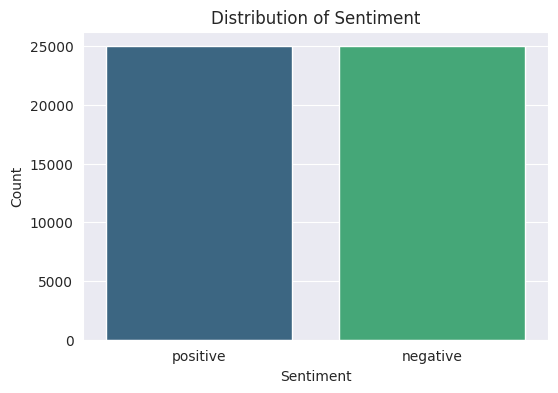

In [ ]:
# Visualize sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

### 2. Panjang Review

Mengetahui karakteristik panjang teks ulasan setelah preprocessing.

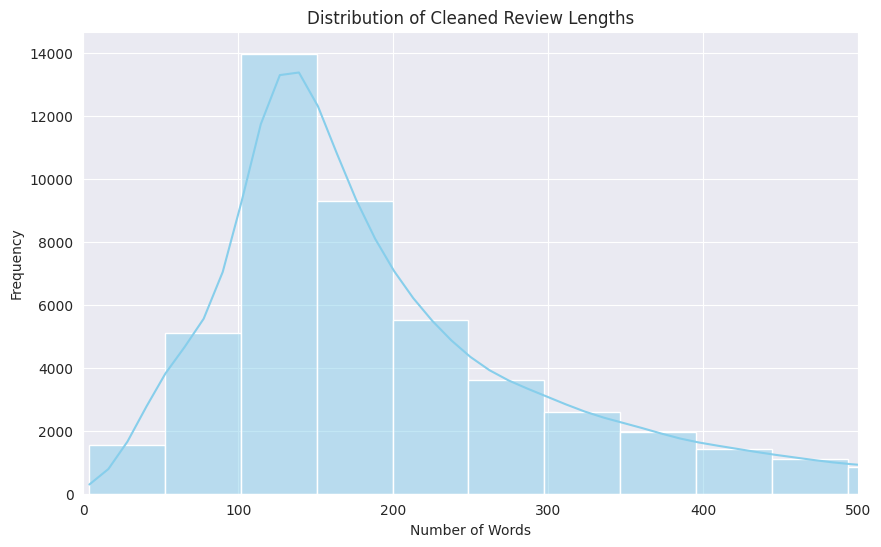

Average cleaned review length: 226.85 words
Maximum cleaned review length: 2450 words


In [ ]:
# Calculate and visualize the distribution of review lengths after cleaning
df['cleaned_review_length'] = df['cleaned_review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['cleaned_review_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Cleaned Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 500) # Limit x-axis for better visualization of the main distribution
plt.show()

print(f"Average cleaned review length: {df['cleaned_review_length'].mean():.2f} words")
print(f"Maximum cleaned review length: {df['cleaned_review_length'].max()} words")

### 3. Akurasi & Loss per Epoch

Memantau performa model selama training. Kita akan memvisualisasikan loss dan akurasi pelatihan dan validasi dari objek `history` yang dihasilkan saat melatih model.

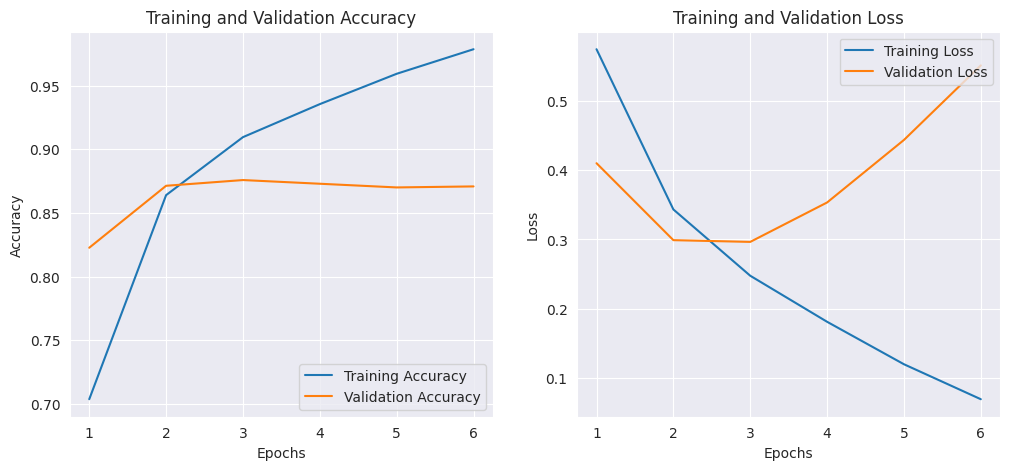

In [ ]:
# Visualize training and validation accuracy and loss
history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

# Get the number of epochs from the history object
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

### 4. Confusion Matrix

Evaluasi detail prediksi model.

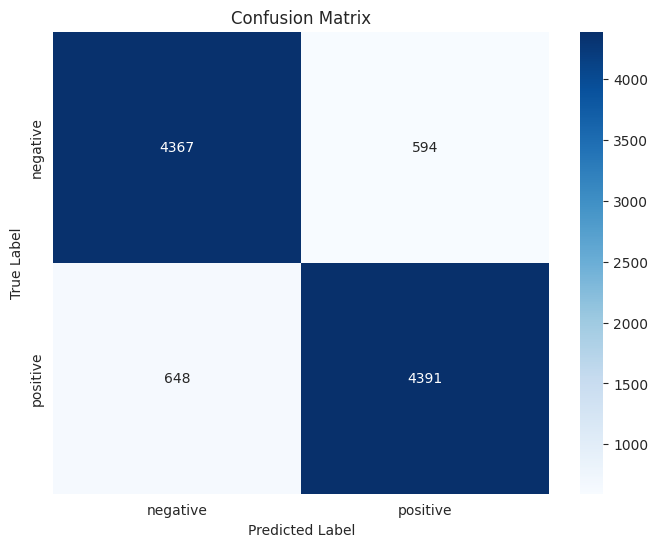

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# The confusion matrix was already calculated in the evaluation step (cell d9ae2089)
# We can reuse the y_true_classes and y_pred_classes from that step.

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5. ROC Curve & AUC (Opsional)

Visualisasi performa klasifikasi.

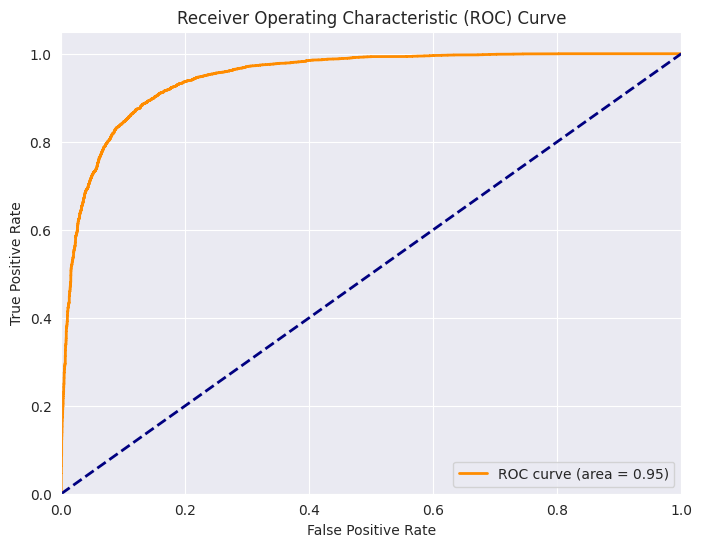

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_classes, y_pred[:, 1]) # Use predicted probabilities for the positive class
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### 6. Word Cloud (Opsional)

Insight dari kata-kata yang sering muncul untuk setiap sentimen.

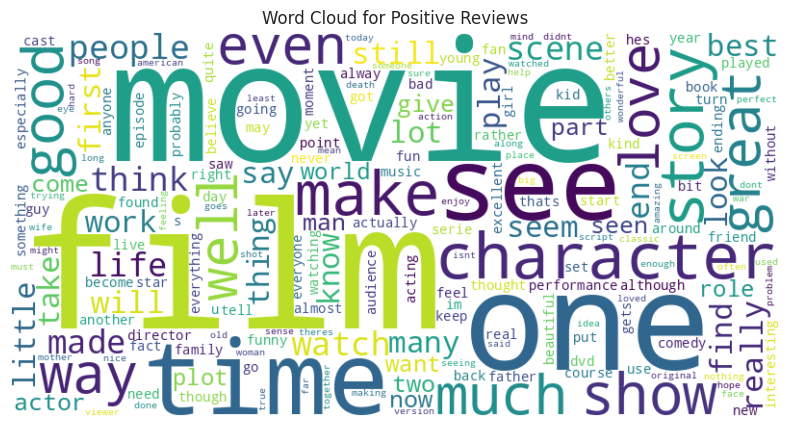

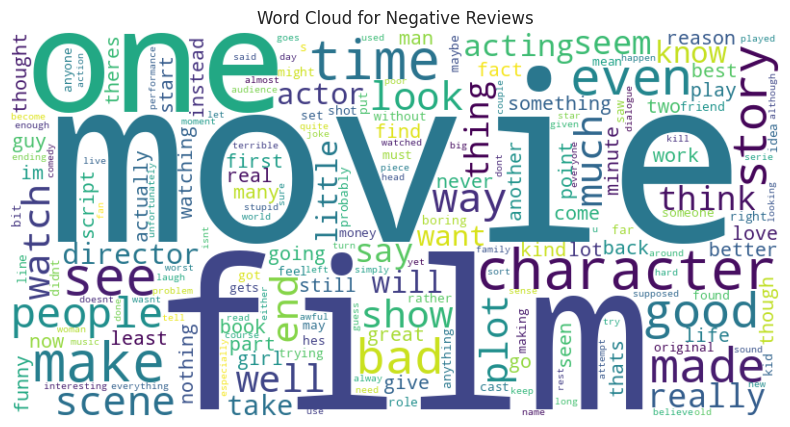

In [ ]:
from wordcloud import WordCloud

# Combine all cleaned reviews for positive and negative sentiments
positive_reviews = " ".join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_reviews = " ".join(df[df['sentiment'] == 'negative']['cleaned_review'])

# Generate Word Cloud for Positive Reviews
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

# Generate Word Cloud for Negative Reviews
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()

# 7. Visualisasi Interaktif atau Visualisasi Secara Realtime

## Instalasi library interaktif


library visualisasi interaktif  terinstal.


In [ ]:
%pip install plotly nbformat

## Visualisasi interaktif akurasi & loss


plot interaktif untuk akurasi dan loss pelatihan dan validasi menggunakan Plotly.


In [ ]:
import plotly.graph_objects as go

# Get data from history object
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

# Get the number of epochs
epochs_range = list(range(1, len(acc) + 1))

# Create accuracy plot
fig_acc = go.Figure()
fig_acc.add_trace(go.Scatter(x=epochs_range, y=acc, mode='lines+markers', name='Training Accuracy'))
fig_acc.add_trace(go.Scatter(x=epochs_range, y=val_acc, mode='lines+markers', name='Validation Accuracy'))
fig_acc.update_layout(title='Training and Validation Accuracy',
                      xaxis_title='Epochs',
                      yaxis_title='Accuracy')
fig_acc.show()

# Create loss plot
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(x=epochs_range, y=loss, mode='lines+markers', name='Training Loss'))
fig_loss.add_trace(go.Scatter(x=epochs_range, y=val_loss, mode='lines+markers', name='Validation Loss'))
fig_loss.update_layout(title='Training and Validation Loss',
                       xaxis_title='Epochs',
                       yaxis_title='Loss')
fig_loss.show()

## Visualisasi interaktif confusion matrix


visualisasi interaktif untuk confusion matrix.


In [ ]:
import plotly.figure_factory as ff

# Create a list of the class labels
class_labels = list(label_encoder.classes_)

# Create the annotated heatmap
fig_cm = ff.create_annotated_heatmap(
    z=cm,  # Confusion matrix data
    x=class_labels,  # Labels for the x-axis (Predicted)
    y=class_labels,  # Labels for the y-axis (True)
    annotation_text=cm.astype(str),  # Convert numbers to strings for annotation
    colorscale='Blues' # Color scheme
)

# Update layout for better visualization
fig_cm.update_layout(
    title='Confusion Matrix',
    xaxis_title='Predicted Label',
    yaxis_title='True Label'
)

# Display the interactive heatmap
fig_cm.show()

# **Pertanyaan Tugas:**

1. Jelaskan Ide dan Kode

   Ceritakan logika pseudocode, alasan pemilihan metode, serta hasil evaluasi.



Penjelasan Ide dan Kode:

Ide utama dari penelitian ini adalah untuk menciptakan sistem otomatis yang bisa membaca ulasan film dan menentukan apakah ulasan tersebut menyatakan sentimen positif (suka) atau negatif (tidak suka), mirip dengan cara manusia melakukannya tetapi dengan bahasa pyhton yang di utarakan seperti hati yang riuh.

Penelitian ini bertujuan untuk mengklasifikasikan sentimen (positif atau negatif) dari ulasan film menggunakan model machine learning. Logikanya adalah:

1. Pengumpulan Data: Menggunakan dataset ulasan film yang sudah ada.
2. Preprocessing Data: Membersihkan teks dari karakter yang tidak relevan (seperti tag HTML dan tanda baca) dan mengubahnya menjadi format yang bisa dipahami oleh model (angka). Ini melibatkan:

 * Menghilangkan tag HTML dan karakter non-alfabet.
 * Mengubah teks menjadi huruf kecil.
 * Tokenisasi: Memecah teks menjadi kata-kata dan memberikan ID unik untuk setiap kata.
 * Padding: Menyamakan panjang semua urutan kata agar model dapat memprosesnya.
 * Encoding Sentimen: Mengubah label sentimen ('positive', 'negative') menjadi angka (0 atau 1) dan kemudian menjadi format one-hot encoding yang sesuai untuk model klasifikasi.

3. Pembagian Data: Memisahkan data yang sudah diproses menjadi data untuk pelatihan (melatih model) dan data untuk pengujian (mengevaluasi seberapa baik model bekerja pada data baru).

4. Pembuatan Model (LSTM): Membangun model jaringan saraf tiruan jenis Bidirectional LSTM. Model ini dipilih karena LSTM (Long Short-Term Memory) sangat baik dalam memahami urutan data (seperti kata-kata dalam kalimat) dan Bidirectional LSTM melihat urutan kata dari dua arah (maju dan mundur), yang membantu dalam memahami konteks sentimen dengan lebih baik.

 * Embedding Layer: Mengubah ID kata menjadi vektor padat yang menangkap makna kata.
 * LSTM Layer: Memproses urutan kata.
   Dense Layers: Layer terakhir untuk melakukan klasifikasi.
 * Dropout Layer: Membantu mencegah overfitting (model terlalu hafal data pelatihan).
5. Pelatihan Model: Melatih model menggunakan data pelatihan. Selama pelatihan, model belajar pola-pola dalam teks yang berkaitan dengan sentimen positif atau negatif. Digunakan Early Stopping untuk menghentikan pelatihan jika kinerja pada data validasi tidak lagi meningkat, ini untuk mencegah overfitting.

6. Evaluasi Model: Menguji model yang sudah dilatih dengan data pengujian yang belum pernah dilihat sebelumnya. Menggunakan metrik seperti akurasi, classification report, dan confusion matrix untuk melihat seberapa baik model memprediksi sentimen.

**Alasan Pemilihan Metode:**

* LSTM: Sangat cocok untuk data sekuensial      seperti teks karena dapat mengingat informasi jangka panjang.
* Bidirectional LSTM: Meningkatkan pemahaman konteks dengan melihat teks dari kedua arah.
* Tokenisasi & Padding: Standar dalam pemrosesan teks untuk mempersiapkan data untuk model deep learning.
* Early Stopping: Penting untuk mencegah model menjadi terlalu spesifik pada data pelatihan dan tidak bekerja dengan baik pada data baru.

**Hasil Evaluasi:**

Hasil evaluasi menunjukkan kinerja model yang baik.

* Loss on test set: 0.2965 (nilai loss yang rendah menunjukkan model membuat prediksi yang cukup akurat).
* Accuracy on test set: 0.8758 (sekitar 87.58% prediksi model benar pada data pengujian).
* Classification Report: Menunjukkan presisi, recall, dan f1-score yang seimbang untuk kedua kelas (positif dan negatif), sekitar 0.88. Ini berarti model cukup baik dalam mengidentifikasi baik ulasan positif maupun negatif tanpa bias yang signifikan.
* Confusion Matrix: Menunjukkan jumlah prediksi benar (diagonal) dan salah (non-diagonal). Angka 4367 dan 4391 menunjukkan jumlah ulasan negatif dan positif yang diprediksi dengan benar. Angka 594 dan 648 menunjukkan kesalahan prediksi.

2. Simpulkan Output dan Pembelajaran

   Jelaskan temuan utama dan manfaat proyek bagi bidang terkait.

Simpulan Output dan Pembelajaran:

**Temuan Utama:**

1. Model Bidirectional LSTM yang dibangun berhasil mengklasifikasikan sentimen ulasan film dengan akurasi sekitar 87.58%.

2. Preprocessing data, termasuk pembersihan teks, tokenisasi, dan padding, sangat penting untuk keberhasilan model.

3. Early Stopping efektif dalam mencegah overfitting, memungkinkan model untuk berkinerja baik pada data yang belum terlihat.

4. Visualisasi data (distribusi sentimen, panjang review, akurasi & loss per epoch, confusion matrix, ROC curve, dan word cloud) memberikan pemahaman yang lebih mendalam tentang data dan kinerja model.

**Manfaat Proyek bagi Bidang Terkait:**

1. Analisis Sentimen Otomatis: Proyek ini menyediakan dasar untuk sistem analisis sentimen otomatis yang dapat digunakan oleh platform film, perusahaan media sosial, atau peneliti pasar untuk memahami opini publik tentang film atau topik lainnya.

2. Peningkatan Pengalaman Pengguna: Platform film dapat menggunakan analisis sentimen untuk menyaring ulasan, merekomendasikan film berdasarkan preferensi sentimen, atau mengidentifikasi tren.

3. Penelitian dan Pengembangan: Proyek ini dapat menjadi titik awal untuk penelitian lebih lanjut dalam analisis sentimen, mencoba arsitektur model yang berbeda, atau menerapkan teknik pemrosesan teks yang lebih canggih.

4. Pemahaman Dataset: Visualisasi yang dilakukan membantu dalam memahami karakteristik dataset ulasan film, seperti distribusi sentimen dan panjang ulasan.